build the mapping + check match rate

XML files downloaded from InBreast Kaggle: 
https://www.kaggle.com/datasets/tommyngx/inbreast2012?resource=download

The paper uses a YOLO technique

In [58]:
from pathlib import Path
import re
import pandas as pd

DICOM_DIR = Path("data/raw/inbreast/ALL-IMGS")
XML_DIR   = Path("data/raw/AllXML")  # or data/raw/inbreast_kaggle/AllXML if you rename it

def leading_id(stem: str) -> str:
    m = re.match(r"(\d+)", stem)
    return m.group(1) if m else stem

dicoms = sorted(DICOM_DIR.glob("*.dcm"))
xmls   = sorted(XML_DIR.glob("*.xml"))

# map id -> path (keep lists in case of duplicates)
dicom_map = {}
for p in dicoms:
    cid = leading_id(p.stem)
    dicom_map.setdefault(cid, []).append(p)

xml_map = {leading_id(p.stem): p for p in xmls}

rows = []
for cid, dcm_list in dicom_map.items():
    for dcm in dcm_list:
        rows.append({
            "case_id": cid,
            "dicom_name": dcm.name,
            "dicom_path": str(dcm),
            "xml_path": str(xml_map[cid]) if cid in xml_map else None,
            "has_xml": cid in xml_map
        })

link_df = pd.DataFrame(rows)

print("DICOM files:", len(dicoms))
print("XML files:", len(xmls))
print("DICOMs with XML:", int(link_df["has_xml"].sum()))
print("DICOMs missing XML:", int((~link_df["has_xml"]).sum()))

display(link_df.sample(10, random_state=0))

# show a few missing examples (useful sanity)
missing = link_df[~link_df["has_xml"]].head(20)
if len(missing):
    print("\nExamples missing XML:")
    display(missing[["case_id","dicom_name"]])

DICOM files: 410
XML files: 343
DICOMs with XML: 343
DICOMs missing XML: 67


,case_id,dicom_name,dicom_path,xml_path,has_xml
295,50998086,50998086_66adfbb4f19c76d2_MG_R_ML_ANON.dcm,data\raw\inbreast\ALL-IMGS\50998086_66adfbb4f1...,data\raw\AllXML\50998086.xml,True
76,22613624,22613624_dcafa6ba6374ec07_MG_R_CC_ANON.dcm,data\raw\inbreast\ALL-IMGS\22613624_dcafa6ba63...,data\raw\AllXML\22613624.xml,True
261,50996379,50996379_6aba0b402889a16f_MG_L_CC_ANON.dcm,data\raw\inbreast\ALL-IMGS\50996379_6aba0b4028...,None,False
374,53582476,53582476_3f0db31711fc9795_MG_R_CC_ANON.dcm,data\raw\inbreast\ALL-IMGS\53582476_3f0db31711...,data\raw\AllXML\53582476.xml,True
299,50998231,50998231_f34ee0ab6591b792_MG_L_CC_ANON.dcm,data\raw\inbreast\ALL-IMGS\50998231_f34ee0ab65...,data\raw\AllXML\50998231.xml,True
145,24055176,24055176_606e9b184978a350_MG_R_ML_ANON.dcm,data\raw\inbreast\ALL-IMGS\24055176_606e9b1849...,data\raw\AllXML\24055176.xml,True
90,22614127,22614127_6bd24a0a42c19ce1_MG_R_ML_ANON.dcm,data\raw\inbreast\ALL-IMGS\22614127_6bd24a0a42...,data\raw\AllXML\22614127.xml,True
10,20587294,20587294_e634830794f5c1bd_MG_R_CC_ANON.dcm,data\raw\inbreast\ALL-IMGS\20587294_e634830794...,data\raw\AllXML\20587294.xml,True
215,50993670,50993670_b03f1dd34eb3c55f_MG_L_ML_ANON.dcm,data\raw\inbreast\ALL-IMGS\50993670_b03f1dd34e...,data\raw\AllXML\50993670.xml,True
328,51048972,51048972_f3e93e889a7746f0_MG_R_CC_ANON.dcm,data\raw\inbreast\ALL-IMGS\51048972_f3e93e889a...,data\raw\AllXML\51048972.xml,True



Examples missing XML:


,case_id,dicom_name
32,20588138,20588138_8d0b9620c53c0268_MG_R_ML_ANON.dcm
33,20588164,20588164_8d0b9620c53c0268_MG_R_CC_ANON.dcm
61,22580218,22580218_5530d5782fc89dd7_MG_L_CC_ANON.dcm
63,22580270,22580270_5530d5782fc89dd7_MG_L_ML_ANON.dcm
83,22613848,22613848_45c7f44839fd9e68_MG_L_ML_ANON.dcm
85,22613944,22613944_f23fa352e7de3dc7_MG_L_CC_ANON.dcm
87,22613996,22613996_f23fa352e7de3dc7_MG_L_ML_ANON.dcm
110,22670442,22670442_7e677f3d530e41ed_MG_R_CC_ANON.dcm
112,22670488,22670488_7e677f3d530e41ed_MG_R_ML_ANON.dcm
115,22670643,22670643_e15a16f87b4f9782_MG_L_CC_ANON.dcm


Cell 1 — Imports + config

In [59]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import pydicom
from tqdm import tqdm
from PIL import Image

from skimage.draw import polygon
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
import plistlib

# =========================
# EDIT THESE PATHS
# =========================
DATA_ROOT = Path("data/raw")   # <-- change
DICOM_DIR = DATA_ROOT / "inbreast/ALL-IMGS"                       # folder with .dcm files (or DICOM files without extension)
XML_DIR   = DATA_ROOT / "AllXML"                             # folder with 12345678.xml files
XLS_PATH  = DATA_ROOT / "inbreast/INbreast.xls"                    # your excel file

OUT_ROOT = DATA_ROOT / "derived_outputs"
OUT_MASS_BENIGN    = OUT_ROOT / "masses" / "benign"
OUT_MASS_MALIGNANT = OUT_ROOT / "masses" / "malignant"
OUT_BG_FATTY       = OUT_ROOT / "background_patches" / "fatty"
OUT_BG_FIBRO       = OUT_ROOT / "background_patches" / "fibroglandular"

for p in [OUT_MASS_BENIGN, OUT_MASS_MALIGNANT, OUT_BG_FATTY, OUT_BG_FIBRO]:
    p.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("DICOM_DIR exists?", DICOM_DIR.exists())
print("XML_DIR exists?", XML_DIR.exists())
print("XLS exists?", XLS_PATH.exists())
print("OUT_ROOT:", OUT_ROOT)

DATA_ROOT: data\raw
DICOM_DIR exists? True
XML_DIR exists? True
XLS exists? True
OUT_ROOT: data\raw\derived_outputs


Cell 2 — index DICOMs by numeric “file id”

In [60]:
def build_dicom_index(dicom_dir: Path):
    idx = {}
    for fp in dicom_dir.rglob("*"):
        if fp.is_dir():
            continue
        # many INbreast dicoms have no extension; accept everything that starts with digits
        m = re.match(r"^(\d+)_", fp.name)
        if m:
            idx[int(m.group(1))] = fp
    return idx

dicom_index = build_dicom_index(DICOM_DIR)
print("Indexed DICOMs:", len(dicom_index))
print("Example:", next(iter(dicom_index.items())) if dicom_index else None)

Indexed DICOMs: 410
Example: (22427705, WindowsPath('data/raw/inbreast/ALL-IMGS/22427705_d713ef5849f98b6c_MG_L_CC_ANON.dcm'))


Cell 3 — load XLS sheets + build a per-image label table

We try to:

find the sheet with File Name + Bi-Rads (image-level)

(optionally) find a sheet with Patient ID + DG (diagnosis), if present


In [61]:
xls = pd.ExcelFile(XLS_PATH)
print("Sheets:", xls.sheet_names)

sheets = {name: xls.parse(name) for name in xls.sheet_names}

def find_sheet_with_cols(required_cols):
    for name, df in sheets.items():
        cols = {c.strip().lower() for c in df.columns.astype(str)}
        if all(rc.lower() in cols for rc in required_cols):
            return name, df
    return None, None

main_name, main_df = find_sheet_with_cols(["File Name", "Bi-Rads"])
if main_df is None:
    raise ValueError("Couldn't find the main sheet with columns: File Name, Bi-Rads")

print("Main sheet:", main_name)
main_df = main_df.rename(columns={c: c.strip() for c in main_df.columns})

# keep only what we need (add ACR if you want)
keep_cols = [c for c in ["File Name", "Bi-Rads", "ACR", "View", "Laterality", "Acquisition date"] if c in main_df.columns]
main = main_df[keep_cols].copy()
main["file_id"] = pd.to_numeric(main["File Name"], errors="coerce").astype("Int64")

# optional diagnosis sheet (DG)
diag_name, diag_df = find_sheet_with_cols(["Patient ID", "DG"])
diag = None
if diag_df is not None:
    diag_df = diag_df.rename(columns={c: c.strip() for c in diag_df.columns})
    diag = diag_df.copy()
    diag["patient_id"] = pd.to_numeric(diag["Patient ID"], errors="coerce").astype("Int64")
    print("Diagnosis sheet:", diag_name, "rows:", len(diag))
else:
    print("No DG diagnosis sheet detected (that's okay).")

def birads_to_int(b):
    """Converts 4a/4b/4c → 4, etc."""
    if pd.isna(b):
        return None
    s = str(b).strip().lower()
    m = re.match(r"^(\d+)", s)
    return int(m.group(1)) if m else None

def birads_to_mass_label(b):
    """
    WARNING:
    BI-RADS is suspicion, not pathology ground truth.
    This mapping is only to satisfy your requested rule.
    """
    bi = birads_to_int(b)
    if bi is None:
        return None
    if bi in [1]:
        return None  # normal / ignore for mass classification
    if bi in [2, 3]:
        return "benign"
    if bi in [4, 5, 6]:
        return "malignant"
    return None

main["birads_int"] = main["Bi-Rads"].apply(birads_to_int)
main["mass_label_from_birads"] = main["Bi-Rads"].apply(birads_to_mass_label)

# Per-image lookup:
image_meta = main.dropna(subset=["file_id"]).drop_duplicates(subset=["file_id"]).set_index("file_id")
print("Unique images with metadata:", len(image_meta))
image_meta.head()

Sheets: ['Sheet1', 'Sheet2']
Main sheet: Sheet1
Diagnosis sheet: Sheet2 rows: 412
Unique images with metadata: 410


,File Name,Bi-Rads,ACR,View,Laterality,Acquisition date,birads_int,mass_label_from_birads
file_id,,,,,,,,
22678622,22678622.0,1,4,CC,R,201001.0,1.0,None
22678646,22678646.0,3,4,CC,L,201001.0,3.0,benign
22678670,22678670.0,1,4,MLO,R,201001.0,1.0,None
22678694,22678694.0,3,4,MLO,L,201001.0,3.0,benign
22614074,22614074.0,5,2,CC,R,201001.0,5.0,malignant


Cell 4 — XML parsing (INbreast XML is a plist)

Many INbreast “.xml” annotations are actually plist XML (OsiriX export). Using plistlib is the simplest reliable parse. This follows a commonly used INbreast parsing pattern.

In [62]:
import re
import numpy as np
import plistlib

_num_re = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

def _parse_point_any(p):
    """
    Accepts:
      - (x, y) tuple/list
      - [x, y] list
      - "(x, y)" string
      - "x, y" string
    Returns (x, y) floats or None.
    """
    # already numeric pair
    if isinstance(p, (list, tuple)) and len(p) == 2:
        try:
            return float(p[0]), float(p[1])
        except Exception:
            return None

    # string "(x, y)" or "x, y"
    if isinstance(p, str):
        nums = _num_re.findall(p)
        if len(nums) >= 2:
            return float(nums[0]), float(nums[1])
        return None

    return None

def _coerce_points(pts):
    """
    Handles:
      - pts = [[x,y], [x,y], ...]
      - pts = ["(x,y)", "(x,y)", ...]
      - pts = "(x,y) (x,y) ..."  (rare)
    Returns Nx2 float array (x,y). Empty array if can't parse.
    """
    out = []

    if pts is None:
        return np.zeros((0, 2), dtype=float)

    # If it's a single string that may contain multiple points
    if isinstance(pts, str):
        nums = _num_re.findall(pts)
        # interpret as x1,y1,x2,y2,...
        for i in range(0, len(nums) - 1, 2):
            out.append((float(nums[i]), float(nums[i+1])))
        return np.array(out, dtype=float) if out else np.zeros((0, 2), dtype=float)

    # If it's a list/tuple of points (strings or numeric pairs)
    if isinstance(pts, (list, tuple)):
        for p in pts:
            xy = _parse_point_any(p)
            if xy is not None:
                out.append(xy)
            else:
                # sometimes it's nested weirdly; try flattening
                if isinstance(p, (list, tuple)) and len(p) > 2:
                    # try reading as consecutive pairs
                    try:
                        flat = list(p)
                        for i in range(0, len(flat) - 1, 2):
                            out.append((float(flat[i]), float(flat[i+1])))
                    except Exception:
                        pass

    return np.array(out, dtype=float) if out else np.zeros((0, 2), dtype=float)

def load_rois_from_inbreast_xml(xml_path):
    """
    Returns list of ROI dicts with:
      - name: ROI name (e.g., 'Mass', 'Calcification')
      - points: Nx2 array of (x, y) pixel points
    """
    with open(xml_path, "rb") as f:
        data = plistlib.load(f)

    img0 = data["Images"][0]
    rois = img0.get("ROIs", [])

    out = []
    for roi in rois:
        name = str(roi.get("Name", "")).strip()

        # OsiriX exports usually have Point_px, but keep fallback if needed
        pts_raw = roi.get("Point_px", None)
        if pts_raw is None:
            pts_raw = roi.get("Points", None)

        pts = _coerce_points(pts_raw)

        # need at least 3 points to form a polygon
        if pts.shape[0] < 3:
            continue

        out.append({"name": name, "points": pts})

    return out

Cell 5 — extract mass crops and save into benign/malignant folders

This:

loops XMLs

loads the corresponding DICOM by file_id

keeps only ROI named "Mass" (case-insensitive)

crops a tight box around the mask (+margin)

labels benign/malignant using BI-RADS mapping from Cell 3

writes .npy (lossless) + a .png preview

In [63]:
def save_patch_npy_and_png(patch, out_stem: Path):
    np.save(str(out_stem.with_suffix(".npy")), patch.astype(np.float32))
    # PNG preview (normalized)
    p = patch.astype(np.float32)
    p = p - np.nanmin(p)
    if np.nanmax(p) > 0:
        p = p / np.nanmax(p)
    img8 = (np.clip(p, 0, 1) * 255).astype(np.uint8)
    Image.fromarray(img8).save(str(out_stem.with_suffix(".png")))

def crop_from_mask(image, mask, margin=20):
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    H, W = image.shape
    y0 = max(0, y0 - margin); y1 = min(H - 1, y1 + margin)
    x0 = max(0, x0 - margin); x1 = min(W - 1, x1 + margin)
    return image[y0:y1+1, x0:x1+1], (y0, y1, x0, x1)

manifest_rows = []

xml_files = sorted(XML_DIR.glob("*.xml"))
print("XML files:", len(xml_files))

for xml_path in tqdm(xml_files):
    file_id = int(xml_path.stem) if xml_path.stem.isdigit() else None
    if file_id is None:
        continue
    if file_id not in dicom_index:
        continue
    if file_id not in image_meta.index:
        continue

    # label from BI-RADS (as requested)
    label_from_birads = image_meta.loc[file_id, "mass_label_from_birads"]
    if label_from_birads not in ["benign", "malignant"]:
        # skip normals/unknowns
        continue

    img = read_dicom_as_float(dicom_index[file_id])
    H, W = img.shape

    rois = load_rois_from_inbreast_xml(xml_path)
    mass_rois = [r for r in rois if r["name"].strip().lower() == "mass"]
    if not mass_rois:
        continue

    out_dir = OUT_MASS_BENIGN if label_from_birads == "benign" else OUT_MASS_MALIGNANT

    for j, roi in enumerate(mass_rois):
        mask = polygon_to_mask(roi["points"], (H, W))
        cropped = crop_from_mask(img, mask, margin=20)
        if cropped is None:
            continue
        patch, (y0, y1, x0, x1) = cropped

        out_stem = out_dir / f"{file_id}_mass{j:02d}"
        save_patch_npy_and_png(patch, out_stem)

        manifest_rows.append({
            "file_id": file_id,
            "roi_index": j,
            "label": label_from_birads,
            "y0": y0, "y1": y1, "x0": x0, "x1": x1,
            "dicom_path": str(dicom_index[file_id]),
            "xml_path": str(xml_path),
            "birads": image_meta.loc[file_id, "Bi-Rads"] if "Bi-Rads" in image_meta.columns else None
        })

manifest = pd.DataFrame(manifest_rows)
manifest_path = OUT_ROOT / "mass_manifest.csv"
manifest.to_csv(manifest_path, index=False)

print("Saved mass crops:", len(manifest))
print("Manifest:", manifest_path)
manifest.head()

XML files: 343


100%|██████████| 343/343 [01:56<00:00,  2.95it/s]

Saved mass crops: 116
Manifest: data\raw\derived_outputs\mass_manifest.csv


,file_id,roi_index,label,y0,y1,x0,x1,dicom_path,xml_path,birads
0,20586908,0,benign,963,1117,2373,2511,data\raw\inbreast\ALL-IMGS\20586908_6c613a14b8...,data\raw\AllXML\20586908.xml,2
1,20586908,1,benign,988,1221,3091,3327,data\raw\inbreast\ALL-IMGS\20586908_6c613a14b8...,data\raw\AllXML\20586908.xml,2
2,20586934,0,malignant,2021,2222,105,331,data\raw\inbreast\ALL-IMGS\20586934_6c613a14b8...,data\raw\AllXML\20586934.xml,5
3,20586960,0,benign,1264,1416,1779,1909,data\raw\inbreast\ALL-IMGS\20586960_6c613a14b8...,data\raw\AllXML\20586960.xml,2
4,20586960,1,benign,794,985,2445,2720,data\raw\inbreast\ALL-IMGS\20586960_6c613a14b8...,data\raw\AllXML\20586960.xml,2


we got 116 masses but the paper had 112 masses

## PATCHING STEP ##

The paper gives the high-level recipe, but not the exact implementation details: remove the mass region, use the remaining breast area to sample random-size background patches, separate fatty vs fibroglandular tissue, then resize patches to 224×224. It also reports 210 fatty and 187 fibroglandular background patches.

So below is a faithful replication strategy that fits your current notebooks:

use your preprocessed images from Step 1.1 (final, breast_mask, pect_mask)

use the XML mass ROIs from Step 1.2 to remove masses

split the remaining breast into darker fatty vs brighter fibroglandular tissue using an Otsu threshold on the enhanced image

sample random square patches from each tissue type

resize them to 224×224

Cell 1 — Imports, paths, and indexing

In [68]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from PIL import Image
from scipy import ndimage as ndi
from skimage.draw import polygon
from skimage.filters import threshold_otsu

# This patching section assumes you already ran the earlier XML parsing cell
assert "load_rois_from_inbreast_xml" in globals(), "Run the earlier XML parsing cell first."

# -----------------------------
# Paths
# -----------------------------
PREPROC_ROOT = Path("data/processed/preproc_v1")
FINAL_DIR = PREPROC_ROOT / "final"
BREAST_MASK_DIR = PREPROC_ROOT / "breast_mask"   # singular
PECT_MASK_DIR   = PREPROC_ROOT / "pect_mask"

XML_DIR = Path("data/raw/AllXML")

PATCH_ROOT = Path("data/processed/patches_v1")
PATCH_BG_FATTY = PATCH_ROOT / "background" / "fatty"
PATCH_BG_FIBRO = PATCH_ROOT / "background" / "fibroglandular"

for p in [PATCH_BG_FATTY, PATCH_BG_FIBRO]:
    p.mkdir(parents=True, exist_ok=True)

# Paper-reported background patch counts
TARGET_COUNTS = {
    "fatty": 210,
    "fibroglandular": 187,
}

RNG = np.random.default_rng(34)

def leading_id(name_or_path) -> int:
    stem = Path(name_or_path).stem
    m = re.match(r"^(\d+)", stem)
    if not m:
        raise ValueError(f"Could not extract leading numeric ID from: {name_or_path}")
    return int(m.group(1))

def build_npy_index(folder: Path):
    idx = {}
    for fp in sorted(folder.glob("*.npy")):
        idx[leading_id(fp.name)] = fp
    return idx

def build_xml_index(folder: Path):
    idx = {}
    for fp in sorted(folder.glob("*.xml")):
        if fp.stem.isdigit():
            idx[int(fp.stem)] = fp
    return idx

final_index = build_npy_index(FINAL_DIR)
bmask_index = build_npy_index(BREAST_MASK_DIR)
pmask_index = build_npy_index(PECT_MASK_DIR)
xml_index   = build_xml_index(XML_DIR)

eligible_ids = sorted(set(final_index) & set(bmask_index) & set(xml_index))

print("final npy files      :", len(final_index))
print("breast mask npy files:", len(bmask_index))
print("pect mask npy files  :", len(pmask_index))
print("xml files            :", len(xml_index))
print("eligible image ids   :", len(eligible_ids))
print("example eligible ids :", eligible_ids[:10])

final npy files      : 410
breast mask npy files: 410
pect mask npy files  : 410
xml files            : 343
eligible image ids   : 343
example eligible ids : [20586908, 20586934, 20586960, 20586986, 20587054, 20587080, 20587148, 20587174, 20587200, 20587226]


Cell 2 — Helper functions for mass masks, tissue masks, and saving patches

What this cell does

This is the core logic:

build_mass_mask(...) reconstructs the lesion region from the XML.

dilate_mask(...) enlarges the mass mask a bit so you do not accidentally sample tissue right on the lesion edge.

split_fatty_vs_fibro(...) separates darker fatty tissue from brighter fibroglandular tissue using Otsu on the mass-removed breast region.

sample_one_patch(...) enforces quality rules so accepted patches are mostly inside the breast, mostly one tissue type, and not nearly duplicates.

That is a sensible implementation of the paper’s under-specified “random size background patching” step. The paper clearly says the remaining breast area is used for random patches, that fatty tissue appears darker and fibroglandular brighter, and that the final patches are resized to 224×224.

In [81]:
def polygon_to_mask(points, shape_hw):
    """
    points: Nx2 array of (x, y)
    shape_hw: (H, W)
    """
    pts = np.asarray(points, dtype=float)
    if pts.shape[0] < 3:
        return np.zeros(shape_hw, dtype=bool)

    rr, cc = polygon(pts[:, 1], pts[:, 0], shape_hw)
    mask = np.zeros(shape_hw, dtype=bool)
    mask[rr, cc] = True
    return mask

def build_mass_mask(file_id: int, shape_hw):
    """
    Union of all ROIs named 'Mass' for this image.
    """
    xml_path = xml_index.get(file_id)
    mask = np.zeros(shape_hw, dtype=bool)

    if xml_path is None:
        return mask

    rois = load_rois_from_inbreast_xml(xml_path)
    mass_rois = [r for r in rois if r["name"].strip().lower() == "mass"]

    for roi in mass_rois:
        mask |= polygon_to_mask(roi["points"], shape_hw)

    return mask

def dilate_mask(mask: np.ndarray, radius: int = 16) -> np.ndarray:
    """
    Dilate the mass mask so we do not sample background patches
    too close to the lesion boundary.
    """
    if radius <= 0:
        return mask.astype(bool)

    y, x = np.ogrid[-radius:radius+1, -radius:radius+1]
    kernel = ((x**2 + y**2) <= radius**2).astype(np.uint8)

    dil = cv2.dilate(mask.astype(np.uint8), kernel, iterations=1)
    return dil.astype(bool)

def clean_binary(mask: np.ndarray, open_size: int = 5, close_size: int = 9, min_area: int = 400):
    """
    Small morphology cleanup + remove tiny islands.
    """
    m = mask.astype(np.uint8)

    k_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_size, open_size))
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_size, close_size))

    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k_open)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k_close)

    n, labels, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    out = np.zeros_like(m)

    for i in range(1, n):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            out[labels == i] = 1

    return out.astype(bool)

def split_fatty_vs_fibro(img01: np.ndarray, allowed_mask: np.ndarray, gap: float = 0.03):
    """
    Split the allowed breast region into:
      - fatty: darker tissue
      - fibroglandular: brighter tissue

    We use Otsu on the allowed pixels, then exclude an ambiguity band
    around the threshold to get cleaner patches.
    """
    vals = img01[allowed_mask]
    vals = vals[np.isfinite(vals)]

    if len(vals) < 20:
        empty = np.zeros_like(allowed_mask, dtype=bool)
        return empty, empty, np.nan

    thr = threshold_otsu(vals)

    fatty = allowed_mask & (img01 <= max(0.0, thr - gap))
    fibro = allowed_mask & (img01 >= min(1.0, thr + gap))

    fatty = clean_binary(fatty, open_size=5, close_size=9, min_area=400)
    fibro = clean_binary(fibro, open_size=5, close_size=9, min_area=400)

    return fatty, fibro, float(thr)

def resize_to_224(patch: np.ndarray) -> np.ndarray:
    return cv2.resize(
        patch.astype(np.float32),
        (224, 224),
        interpolation=cv2.INTER_AREA
    ).astype(np.float32)

def save_patch_npy_and_png(patch01: np.ndarray, out_stem: Path):
    np.save(str(out_stem.with_suffix(".npy")), patch01.astype(np.float32))

    p = patch01.astype(np.float32)
    p = p - np.nanmin(p)
    if np.nanmax(p) > 0:
        p = p / np.nanmax(p)

    img8 = (np.clip(p, 0, 1) * 255).astype(np.uint8)
    Image.fromarray(img8).save(str(out_stem.with_suffix(".png")))

def box_iou(box_a, box_b):
    """
    box = (y0, y1, x0, x1)
    """
    ay0, ay1, ax0, ax1 = box_a
    by0, by1, bx0, bx1 = box_b

    iy0, iy1 = max(ay0, by0), min(ay1, by1)
    ix0, ix1 = max(ax0, bx0), min(ax1, bx1)

    inter_h = max(0, iy1 - iy0 + 1)
    inter_w = max(0, ix1 - ix0 + 1)
    inter = inter_h * inter_w

    area_a = (ay1 - ay0 + 1) * (ax1 - ax0 + 1)
    area_b = (by1 - by0 + 1) * (bx1 - bx0 + 1)
    union = area_a + area_b - inter

    return inter / max(union, 1)

def boxes_intersect(box_a, box_b):
    """
    box = (y0, y1, x0, x1), inclusive coordinates
    Returns True if the two boxes overlap at all.
    """
    ay0, ay1, ax0, ax1 = box_a
    by0, by1, bx0, bx1 = box_b

    if ax1 < bx0 or bx1 < ax0:
        return False
    if ay1 < by0 or by1 < ay0:
        return False
    return True


def boxes_intersect(box_a, box_b):
    """
    box = (y0, y1, x0, x1), inclusive coordinates
    Returns True if the two boxes overlap at all.
    """
    ay0, ay1, ax0, ax1 = box_a
    by0, by1, bx0, bx1 = box_b

    if ax1 < bx0 or bx1 < ax0:
        return False
    if ay1 < by0 or by1 < ay0:
        return False
    return True


def sample_one_patch(
    img01: np.ndarray,
    allowed_mask: np.ndarray,
    target_mask: np.ndarray,
    used_boxes=None,
    sizes=(96, 128, 160, 192, 224, 256),
    min_allowed_frac=0.90,
    min_target_frac=0.75,
    min_std=0.035,
    max_tries=600,
    rng=None,
    forbid_any_overlap=True,
    max_iou=0.0,
    require_full_containment=True,
):
    """
    Randomly sample one square patch from target_mask and accept it only if:
    - it is fully inside allowed_mask (if require_full_containment=True)
    - most of the patch belongs to the requested class
    - the patch is not too flat
    - it does not overlap previously accepted patches
    """
    if rng is None:
        rng = np.random.default_rng(0)
    if used_boxes is None:
        used_boxes = []

    H, W = img01.shape
    ys, xs = np.where(target_mask)

    if len(xs) == 0:
        return None

    for _ in range(max_tries):
        s = int(rng.choice(sizes))
        idx = int(rng.integers(0, len(xs)))
        cy, cx = int(ys[idx]), int(xs[idx])

        y0 = cy - s // 2
        x0 = cx - s // 2
        y1 = y0 + s
        x1 = x0 + s

        if y0 < 0 or x0 < 0 or y1 > H or x1 > W:
            continue

        patch_allowed = allowed_mask[y0:y1, x0:x1]
        patch_target = target_mask[y0:y1, x0:x1]

        if require_full_containment:
            if patch_allowed.shape != (s, s):
                continue
            if not np.all(patch_allowed):
                continue
            allowed_frac = 1.0
        else:
            allowed_frac = patch_allowed.mean()
            if allowed_frac < min_allowed_frac:
                continue

        valid_pixels = int(patch_allowed.sum())
        if valid_pixels == 0:
            continue

        target_frac = patch_target.sum() / valid_pixels
        if target_frac < min_target_frac:
            continue

        box = (y0, y1 - 1, x0, x1 - 1)

        if forbid_any_overlap:
            if any(boxes_intersect(box, old_box) for old_box in used_boxes):
                continue
        else:
            if any(box_iou(box, old_box) > max_iou for old_box in used_boxes):
                continue

        patch = img01[y0:y1, x0:x1].copy()
        vals = patch[patch_allowed]

        if len(vals) < 50:
            continue
        if np.nanstd(vals) < min_std:
            continue

        patch[~patch_allowed] = 0.0
        patch224 = resize_to_224(patch)

        return {
            "patch": patch224,
            "orig_size": s,
            "y0": y0, "y1": y1 - 1,
            "x0": x0, "x1": x1 - 1,
            "allowed_frac": float(allowed_frac),
            "target_frac": float(target_frac),
            "mean_intensity": float(np.nanmean(vals)),
            "std_intensity": float(np.nanstd(vals)),
        }

    return None


def get_bbox_from_mask(mask: np.ndarray):
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    return ys.min(), ys.max(), xs.min(), xs.max()

def make_relative_patch_sizes(
    allowed_mask: np.ndarray,
    fracs=(0.14, 0.18, 0.22, 0.26, 0.30),
    min_px=160,
    max_px=512
):
    """
    Choose patch sizes as fractions of the breast-region bounding box.
    This is better than fixed sizes because mammograms have different scales.
    """
    bbox = get_bbox_from_mask(allowed_mask)
    if bbox is None:
        return [160, 192, 224, 256]

    y0, y1, x0, x1 = bbox
    h = y1 - y0 + 1
    w = x1 - x0 + 1
    ref = min(h, w)

    sizes = []
    for f in fracs:
        s = int(round(ref * f))
        s = max(min_px, min(max_px, s))
        sizes.append(s)

    # unique + sorted
    sizes = sorted(set(sizes))
    return sizes

Cell 3 — Visual sanity check on one example image

What you want to see here

You should see:

red region covering the mass

the allowed region excluding mass and pectoral

fatty patches mainly on darker breast areas

fibroglandular patches mainly on brighter dense areas

sample_id: 20586908
image shape: (4084, 3328)
mass pixels: 36498
allowed pixels: 5093776
threshold: 0.6812576651573181


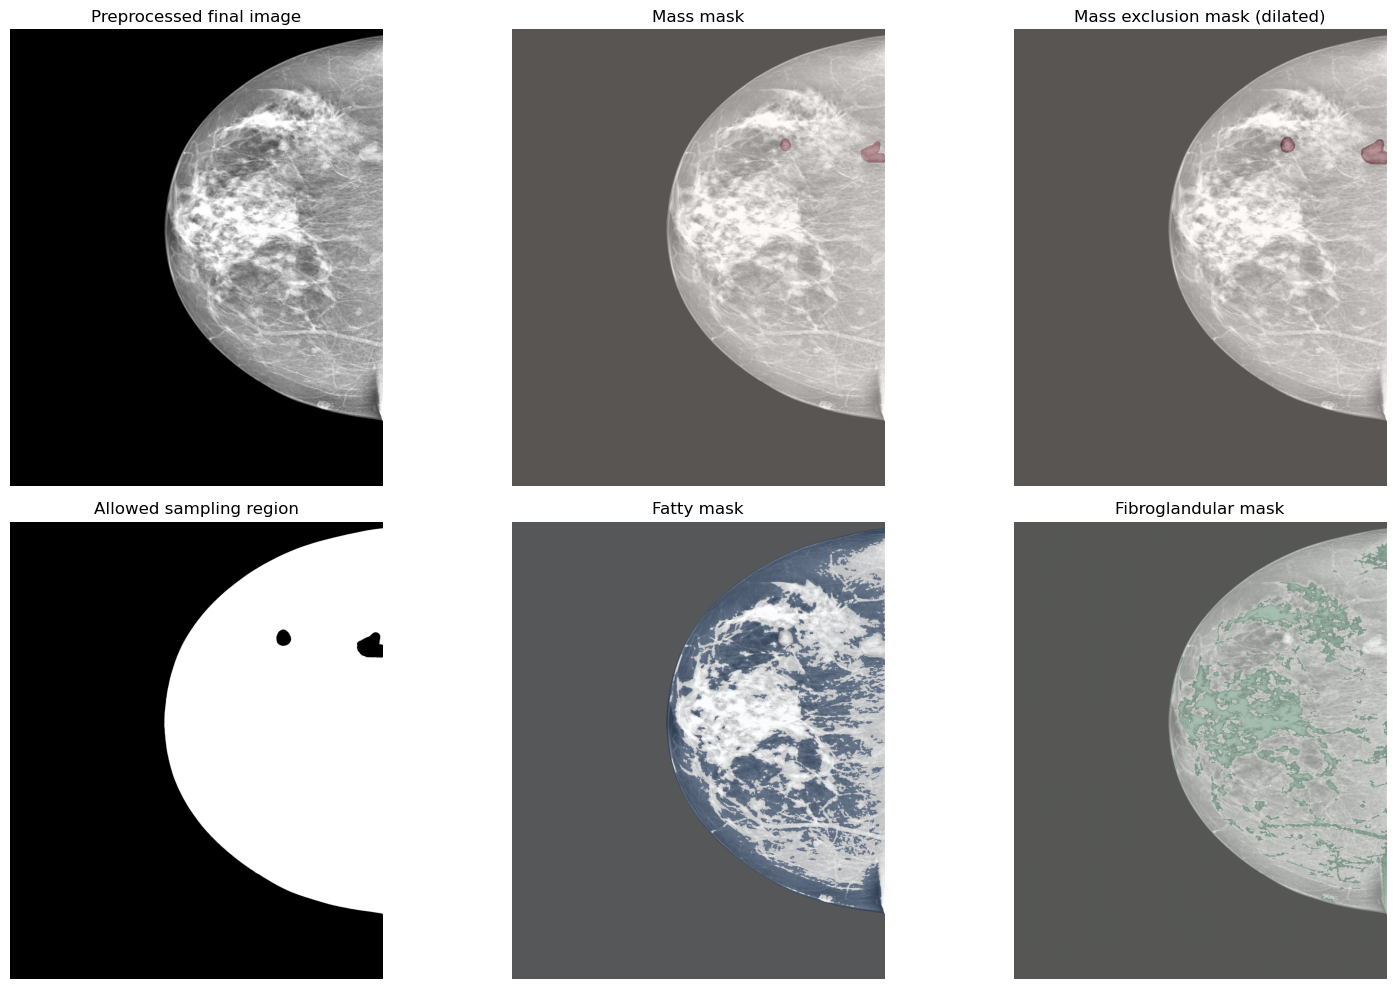

In [82]:
# Pick one example case that has all needed files
sample_id = eligible_ids[0]

img = np.load(final_index[sample_id]).astype(np.float32)
breast_mask = np.load(bmask_index[sample_id]).astype(bool)
pect_mask = np.load(pmask_index[sample_id]).astype(bool) if sample_id in pmask_index else np.zeros_like(breast_mask, dtype=bool)

mass_mask = build_mass_mask(sample_id, img.shape)
mass_excl = dilate_mask(mass_mask, radius=16)

allowed_mask = breast_mask & (~pect_mask) & (~mass_excl)
fatty_mask, fibro_mask, thr = split_fatty_vs_fibro(img, allowed_mask, gap=0.03)

print("sample_id:", sample_id)
print("image shape:", img.shape)
print("mass pixels:", int(mass_mask.sum()))
print("allowed pixels:", int(allowed_mask.sum()))
print("threshold:", thr)

plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Preprocessed final image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(img, cmap="gray")
plt.imshow(mass_mask, alpha=0.35, cmap="Reds")
plt.title("Mass mask")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(mass_excl, alpha=0.35, cmap="Reds")
plt.title("Mass exclusion mask (dilated)")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(allowed_mask, cmap="gray")
plt.title("Allowed sampling region")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(img, cmap="gray")
plt.imshow(fatty_mask, alpha=0.35, cmap="Blues")
plt.title("Fatty mask")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(img, cmap="gray")
plt.imshow(fibro_mask, alpha=0.35, cmap="Greens")
plt.title("Fibroglandular mask")
plt.axis("off")

plt.tight_layout()
plt.show()

Cell 4 — Test the sampler on one image before running the full batch

What this cell checks

Before you batch-save hundreds of patches, make sure the accepted examples actually look like the class you expect. Darker, less dense regions should dominate the fatty patches; brighter, denser texture should dominate the fibroglandular patches.

This version uses:

larger patch sizes

sizes relative to the breast

zoomed plotting

actual patch previews

sample_id: 20586908
image shape: (4084, 3328)
mass pixels: 36498
excluded mass pixels: 62419
allowed pixels: 5084625
threshold: 0.6812576651573181
patch sizes being tested: [273, 351, 429, 507, 512]


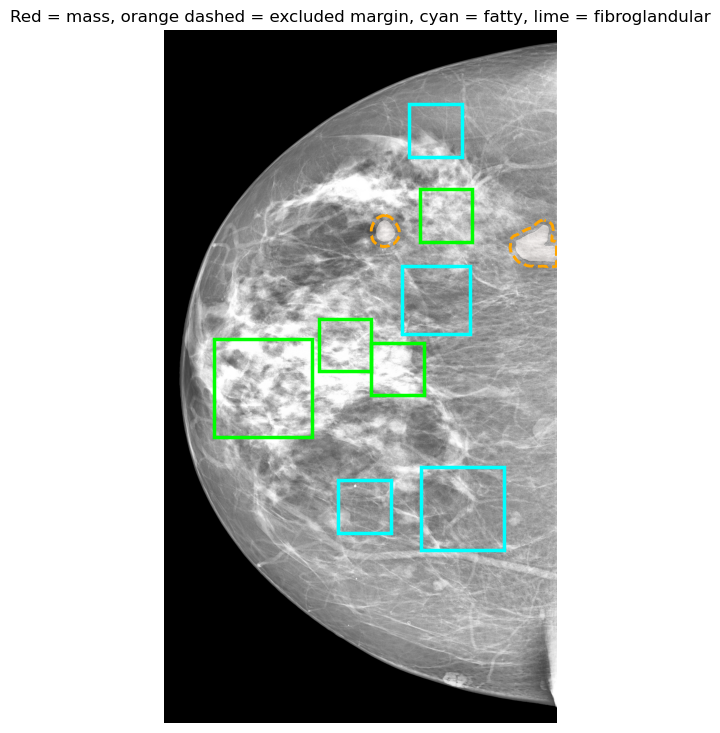

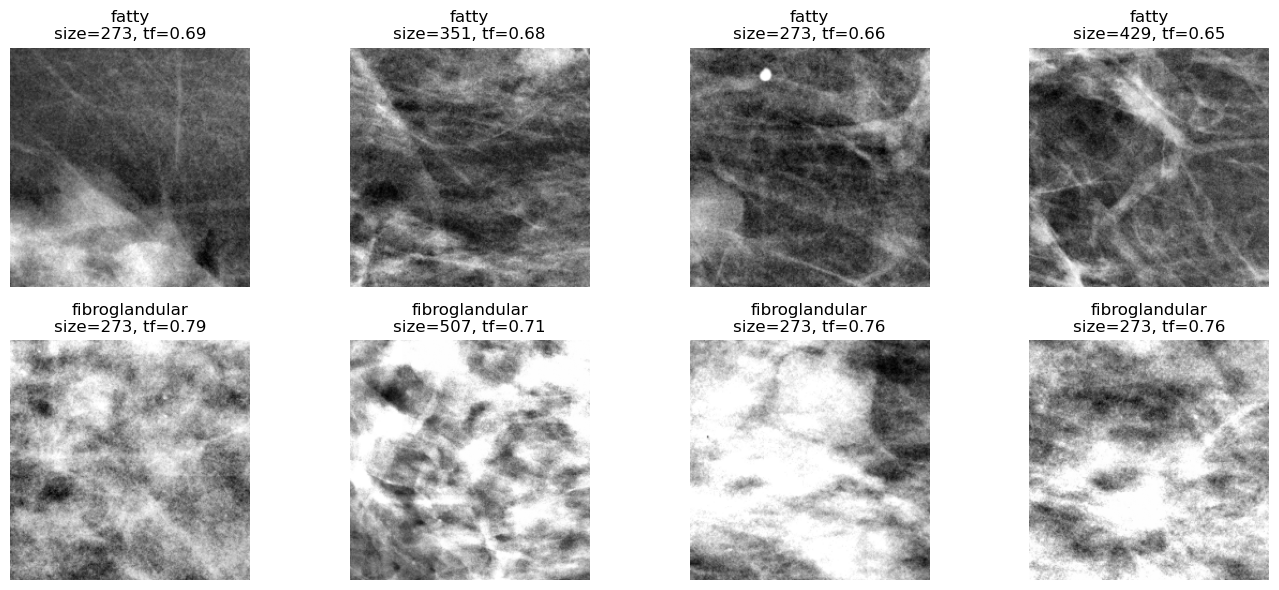

fatty patches accepted: 4
fibroglandular patches accepted: 4
total accepted patches: 8


In [84]:
# ---------------------------------
# Cell 4: Test sampler on one image
# ---------------------------------

sample_id = eligible_ids[0]

img = np.load(final_index[sample_id]).astype(np.float32)
breast_mask = np.load(bmask_index[sample_id]).astype(bool)
pect_mask = np.load(pmask_index[sample_id]).astype(bool) if sample_id in pmask_index else np.zeros_like(breast_mask, dtype=bool)

# More conservative exclusion around the mass
MASS_DILATION_RADIUS_DEBUG = 24

mass_mask = build_mass_mask(sample_id, img.shape)
mass_excl = dilate_mask(mass_mask, radius=MASS_DILATION_RADIUS_DEBUG)

allowed_mask = breast_mask & (~pect_mask) & (~mass_excl)
fatty_mask, fibro_mask, thr = split_fatty_vs_fibro(img, allowed_mask, gap=0.03)

patch_sizes = make_relative_patch_sizes(
    allowed_mask,
    fracs=(0.14, 0.18, 0.22, 0.26, 0.30),
    min_px=160,
    max_px=512
)

print("sample_id:", sample_id)
print("image shape:", img.shape)
print("mass pixels:", int(mass_mask.sum()))
print("excluded mass pixels:", int(mass_excl.sum()))
print("allowed pixels:", int(allowed_mask.sum()))
print("threshold:", thr)
print("patch sizes being tested:", patch_sizes)

used_boxes_all = []
fatty_examples = []
fibro_examples = []

# sample fatty patches
for _ in range(4):
    s = sample_one_patch(
        img01=img,
        allowed_mask=allowed_mask,
        target_mask=fatty_mask,
        used_boxes=used_boxes_all,
        sizes=patch_sizes,
        min_target_frac=0.65,
        rng=RNG,
        forbid_any_overlap=True,
        require_full_containment=True,
        max_tries=800,
    )
    if s is not None:
        used_boxes_all.append((s["y0"], s["y1"], s["x0"], s["x1"]))
        fatty_examples.append(s)

# sample fibroglandular patches
for _ in range(4):
    s = sample_one_patch(
        img01=img,
        allowed_mask=allowed_mask,
        target_mask=fibro_mask,
        used_boxes=used_boxes_all,
        sizes=patch_sizes,
        min_target_frac=0.65,
        rng=RNG,
        forbid_any_overlap=True,
        require_full_containment=True,
        max_tries=800,
    )
    if s is not None:
        used_boxes_all.append((s["y0"], s["y1"], s["x0"], s["x1"]))
        fibro_examples.append(s)

# ---------------------------------
# Plot 1: zoomed source image + mass + exclusion margin + boxes
# ---------------------------------
bbox = get_bbox_from_mask(breast_mask)
y0b, y1b, x0b, x1b = bbox
pad = 80

yy0 = max(0, y0b - pad)
yy1 = min(img.shape[0], y1b + pad)
xx0 = max(0, x0b - pad)
xx1 = min(img.shape[1], x1b + pad)

plt.figure(figsize=(9, 9))
plt.imshow(img, cmap="gray")

# True mass highlighted in red
plt.imshow(np.ma.masked_where(~mass_mask, mass_mask), cmap="Reds", alpha=0.35)

# Exclusion margin outline in orange dashed
mass_excl_contours, _ = cv2.findContours(
    mass_excl.astype(np.uint8),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
for cnt in mass_excl_contours:
    cnt = cnt.squeeze()
    if cnt.ndim == 2 and len(cnt) >= 3:
        plt.plot(cnt[:, 0], cnt[:, 1], color="orange", linewidth=2, linestyle="--")

# fatty boxes
for s in fatty_examples:
    rect = plt.Rectangle(
        (s["x0"], s["y0"]),
        s["x1"] - s["x0"] + 1,
        s["y1"] - s["y0"] + 1,
        fill=False,
        edgecolor="cyan",
        linewidth=2.5
    )
    plt.gca().add_patch(rect)

# fibroglandular boxes
for s in fibro_examples:
    rect = plt.Rectangle(
        (s["x0"], s["y0"]),
        s["x1"] - s["x0"] + 1,
        s["y1"] - s["y0"] + 1,
        fill=False,
        edgecolor="lime",
        linewidth=2.5
    )
    plt.gca().add_patch(rect)

plt.xlim(xx0, xx1)
plt.ylim(yy1, yy0)
plt.title("Red = mass, orange dashed = excluded margin, cyan = fatty, lime = fibroglandular")
plt.axis("off")
plt.show()

# ---------------------------------
# Plot 2: show actual resized patches
# ---------------------------------
all_examples = [("fatty", x) for x in fatty_examples] + [("fibroglandular", x) for x in fibro_examples]

plt.figure(figsize=(14, 6))
for i, (label, s) in enumerate(all_examples[:8], start=1):
    plt.subplot(2, 4, i)
    plt.imshow(s["patch"], cmap="gray")
    plt.title(
        f"{label}\n"
        f"size={s['orig_size']}, tf={s['target_frac']:.2f}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

print(f"fatty patches accepted: {len(fatty_examples)}")
print(f"fibroglandular patches accepted: {len(fibro_examples)}")
print(f"total accepted patches: {len(fatty_examples) + len(fibro_examples)}")

We stop taking patches once we have the same number as in the paper

In [85]:
# ---------------------------------
# Cell 5: Batch extraction and save
# ---------------------------------

MAX_PER_IMAGE_PER_CLASS = 3
STRICT_GAP = 0.03
MASS_DILATION_RADIUS = 24   # increased from 16 to reduce mass-touching patches

records = []
counts = {"fatty": 0, "fibroglandular": 0}

# Optional: clear old patches for a clean rerun
for folder in [PATCH_BG_FATTY, PATCH_BG_FIBRO]:
    for fp in folder.glob("*.npy"):
        fp.unlink()
    for fp in folder.glob("*.png"):
        fp.unlink()

for file_id in tqdm(eligible_ids, desc="Extracting background patches"):
    if all(counts[k] >= TARGET_COUNTS[k] for k in TARGET_COUNTS):
        break

    img = np.load(final_index[file_id]).astype(np.float32)
    breast_mask = np.load(bmask_index[file_id]).astype(bool)
    pect_mask = np.load(pmask_index[file_id]).astype(bool) if file_id in pmask_index else np.zeros_like(breast_mask, dtype=bool)

    mass_mask = build_mass_mask(file_id, img.shape)
    if mass_mask.sum() == 0:
        continue

    mass_excl = dilate_mask(mass_mask, radius=MASS_DILATION_RADIUS)
    allowed_mask = breast_mask & (~pect_mask) & (~mass_excl)

    if allowed_mask.sum() < 5000:
        continue

    fatty_mask, fibro_mask, thr = split_fatty_vs_fibro(img, allowed_mask, gap=STRICT_GAP)

    patch_sizes = make_relative_patch_sizes(
        allowed_mask,
        fracs=(0.14, 0.18, 0.22, 0.26, 0.30),
        min_px=160,
        max_px=512
    )

    # One shared list for both classes
    per_image_boxes_all = []

    for label, target_mask, out_dir in [
        ("fatty", fatty_mask, PATCH_BG_FATTY),
        ("fibroglandular", fibro_mask, PATCH_BG_FIBRO),
    ]:
        n_added_here = 0

        while counts[label] < TARGET_COUNTS[label] and n_added_here < MAX_PER_IMAGE_PER_CLASS:
            sampled = sample_one_patch(
                img01=img,
                allowed_mask=allowed_mask,
                target_mask=target_mask,
                used_boxes=per_image_boxes_all,
                sizes=patch_sizes,
                min_target_frac=0.65,
                rng=RNG,
                forbid_any_overlap=True,
                require_full_containment=True,
                max_tries=800,
            )

            if sampled is None:
                break

            box = (sampled["y0"], sampled["y1"], sampled["x0"], sampled["x1"])
            per_image_boxes_all.append(box)

            patch_idx = counts[label]
            out_stem = out_dir / f"{file_id}_{label}_{patch_idx:03d}"

            save_patch_npy_and_png(sampled["patch"], out_stem)

            records.append({
                "file_id": file_id,
                "label": label,
                "patch_npy": str(out_stem.with_suffix(".npy")),
                "patch_png": str(out_stem.with_suffix(".png")),
                "source_final_npy": str(final_index[file_id]),
                "source_breast_mask_npy": str(bmask_index[file_id]),
                "source_pect_mask_npy": str(pmask_index[file_id]) if file_id in pmask_index else None,
                "xml_path": str(xml_index[file_id]),
                "threshold": thr,
                "orig_size": sampled["orig_size"],
                "y0": sampled["y0"],
                "y1": sampled["y1"],
                "x0": sampled["x0"],
                "x1": sampled["x1"],
                "allowed_frac": sampled["allowed_frac"],
                "target_frac": sampled["target_frac"],
                "mean_intensity": sampled["mean_intensity"],
                "std_intensity": sampled["std_intensity"],
            })

            counts[label] += 1
            n_added_here += 1

manifest_bg = pd.DataFrame(records)
manifest_path = PATCH_ROOT / "manifest.csv"
manifest_bg.to_csv(manifest_path, index=False)

print("Saved manifest:", manifest_path)
print("Counts:", counts)
display(manifest_bg.head())

Extracting background patches:  62%|██████▏   | 214/343 [05:24<03:15,  1.52s/it]


Saved manifest: data\processed\patches_v1\manifest.csv
Counts: {'fatty': 210, 'fibroglandular': 187}


,file_id,label,patch_npy,patch_png,source_final_npy,source_breast_mask_npy,source_pect_mask_npy,xml_path,threshold,orig_size,y0,y1,x0,x1,allowed_frac,target_frac,mean_intensity,std_intensity
0,20586908,fatty,data\processed\patches_v1\background\fatty\205...,data\processed\patches_v1\background\fatty\205...,data\processed\preproc_v1\final\20586908_6c613...,data\processed\preproc_v1\breast_mask\20586908...,data\processed\preproc_v1\pect_mask\20586908_6...,data\raw\AllXML\20586908.xml,0.681258,273,887,1159,1958,2230,1.0,0.864751,0.523079,0.109092
1,20586908,fatty,data\processed\patches_v1\background\fatty\205...,data\processed\patches_v1\background\fatty\205...,data\processed\preproc_v1\final\20586908_6c613...,data\processed\preproc_v1\breast_mask\20586908...,data\processed\preproc_v1\pect_mask\20586908_6...,data\raw\AllXML\20586908.xml,0.681258,273,244,516,2691,2963,1.0,0.712219,0.604453,0.060220
2,20586908,fatty,data\processed\patches_v1\background\fatty\205...,data\processed\patches_v1\background\fatty\205...,data\processed\preproc_v1\final\20586908_6c613...,data\processed\preproc_v1\breast_mask\20586908...,data\processed\preproc_v1\pect_mask\20586908_6...,data\raw\AllXML\20586908.xml,0.681258,273,2080,2352,2066,2338,1.0,0.756752,0.583349,0.112752
3,20586908,fibroglandular,data\processed\patches_v1\background\fibroglan...,data\processed\patches_v1\background\fibroglan...,data\processed\preproc_v1\final\20586908_6c613...,data\processed\preproc_v1\breast_mask\20586908...,data\processed\preproc_v1\pect_mask\20586908_6...,data\raw\AllXML\20586908.xml,0.681258,351,1415,1765,1848,2198,1.0,0.762096,0.836919,0.135106
4,20586908,fibroglandular,data\processed\patches_v1\background\fibroglan...,data\processed\patches_v1\background\fibroglan...,data\processed\preproc_v1\final\20586908_6c613...,data\processed\preproc_v1\breast_mask\20586908...,data\processed\preproc_v1\pect_mask\20586908_6...,data\raw\AllXML\20586908.xml,0.681258,273,713,985,2740,3012,1.0,0.698855,0.783806,0.107647


Summary

Final counts from manifest:


label
fatty             210
fibroglandular    187
Name: count, dtype: int64


Unique source images used per class:


label
fatty             76
fibroglandular    65
Name: file_id, dtype: int64


Patch size distribution:


...

count    397.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: allowed_frac, dtype: float64


Target fraction summary:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
fatty,210.0,0.752584,0.082816,0.650521,0.689852,0.731587,0.800651,1.0
fibroglandular,187.0,0.765597,0.096435,0.651763,0.684354,0.741761,0.821415,1.0



Intensity summary:


mean_intensity                               std_intensity  \
                         mean       std       min       max          mean   
label                                                                       
fatty                0.562165  0.056995  0.411842  0.680079      0.100570   
fibroglandular       0.794455  0.059148  0.575881  0.915336      0.113715   

                                              
                     std       min       max  
label                                         
fatty           0.031994  0.041005  0.235380  
fibroglandular  0.033054  0.040746  0.199217

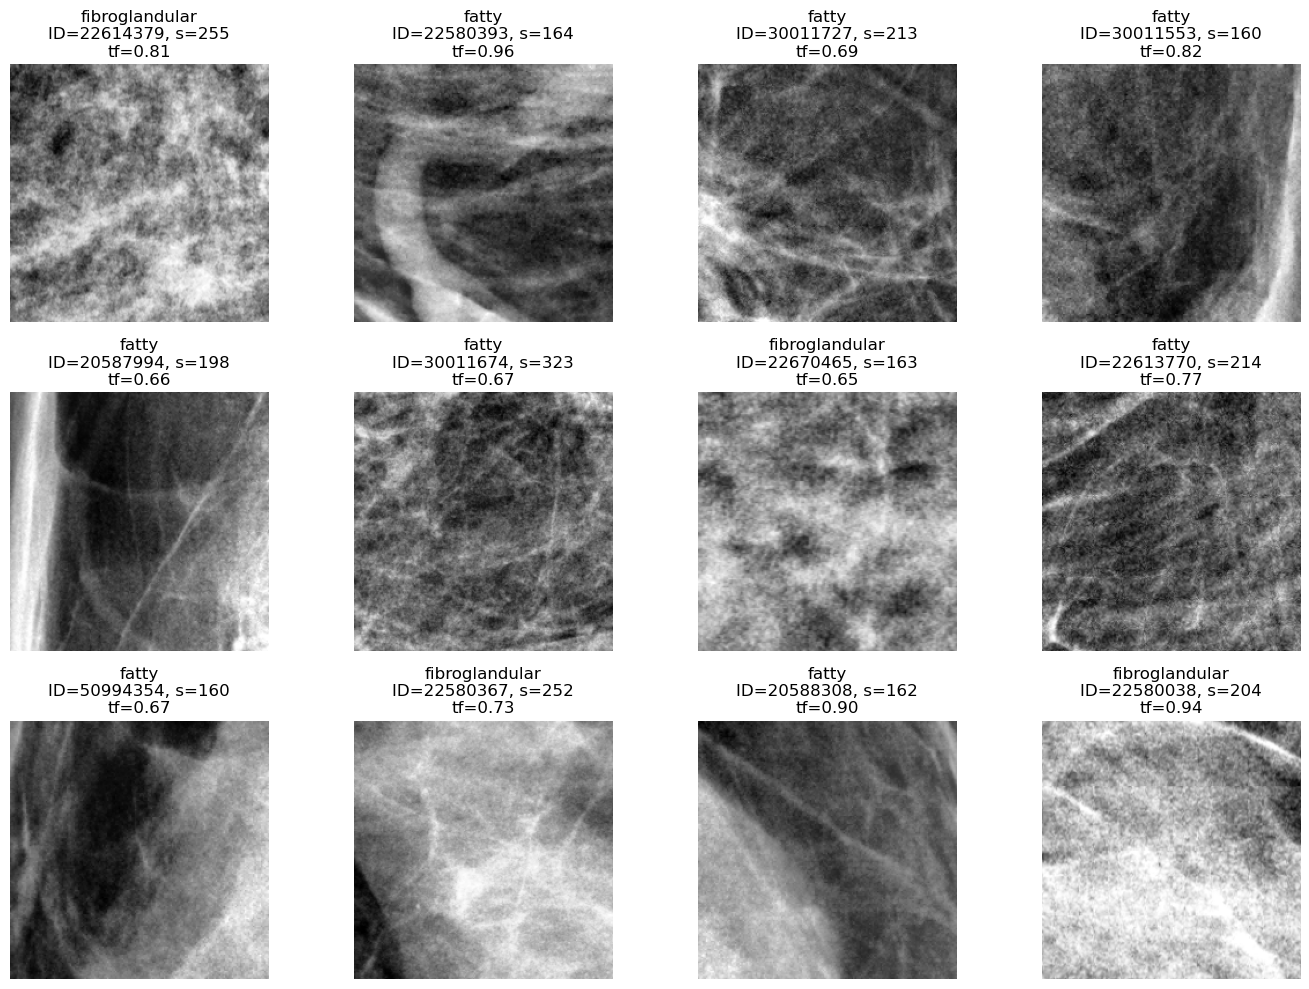

In [86]:
# ---------------------------------
# Cell 6: Summary and QC
# ---------------------------------

print("Final counts from manifest:")
display(manifest_bg["label"].value_counts())

print("\nUnique source images used per class:")
display(manifest_bg.groupby("label")["file_id"].nunique())

print("\nPatch size distribution:")
display(manifest_bg["orig_size"].value_counts().sort_index())

print("\nAllowed fraction summary:")
display(manifest_bg["allowed_frac"].describe())

print("\nTarget fraction summary:")
display(manifest_bg.groupby("label")["target_frac"].describe())

print("\nIntensity summary:")
display(
    manifest_bg.groupby("label")[["mean_intensity", "std_intensity"]]
    .agg(["mean", "std", "min", "max"])
)

# Show a few random saved patches
if len(manifest_bg) > 0:
    show_df = manifest_bg.sample(min(12, len(manifest_bg)), random_state=34).reset_index(drop=True)

    plt.figure(figsize=(14, 10))
    for i, row in show_df.iterrows():
        patch = np.load(row["patch_npy"])
        plt.subplot(3, 4, i + 1)
        plt.imshow(patch, cmap="gray")
        plt.title(
            f"{row['label']}\n"
            f"ID={row['file_id']}, s={row['orig_size']}\n"
            f"tf={row['target_frac']:.2f}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("manifest_bg is empty — no patches were saved.")